# LSTM-Autoencoder Feature Selection Comparison

This notebook implements a memory-efficient pipeline to compare three feature selection algorithms for anomaly detection using the CSE-CICIDS2018 dataset.

**Key Implementation Details:**
1. **Iterative Loading**: Processing data file-by-file to handle 16M+ rows without OOM.
2. **Temporal Splitting**: Splitting Benign data sequentially (no shuffle) to preserve LSTM dependencies.
3. **Benign Split Logic**: 
   - If Benign > 1M: Train = first 500k, Test = rest.
   - If Benign $\le$ 1M: 50:50 split (Test $\ge$ Train).
4. **Memory Optimization**: Downcasting to `float32`, bounded streaming sampling for feature selection, and append-only Parquet preprocessing.
5. **Threshold**: Set as the 95th percentile of the training Anomaly Score reconstruction error.

In [1]:
import json
import pickle
import pyarrow.parquet as pq
import pyarrow as pa
import os
import glob
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, RFE
from mrmr import mrmr_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, precision_recall_curve, auc
)
import matplotlib.pyplot as plt
import time
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# --- Configuration ---
DATASET_DIR = "/home/dhani/AnomalyIDS/dataset"
TIME_STEPS = 10
HIDDEN_DIM = 64
LEARNING_RATE = 0.001
DROPOUT = 0.2
BATCH_SIZE = 64
EPOCHS = 30
K_FEATURES = 10  # Number of features to select
BENIGN_TRAIN_CAP = 500000
BENIGN_THRESHOLD_LIMIT = 1000000
CSV_CHUNK_SIZE = 50000
PARQUET_BATCH_SIZE = 32768
FS_SAMPLE_PER_CLASS = 20000
RFE_SAMPLE_PER_CLASS = 5000
RF_ESTIMATORS = 25
RFE_RF_ESTIMATORS = 10
RFE_STEP = 5
THRESHOLD_PERCENTILE = 95
CORRELATION_THRESHOLD = 0.9
ARTIFACTS_DIR = "artifacts"

In [3]:
def optimize_df(df):
    """Store all numeric features as float32 for consistent low-memory batches."""
    numeric_cols = [col for col in df.columns if col != 'Label']
    df[numeric_cols] = df[numeric_cols].astype('float32')
    return df

def get_shared_feature_columns(dataset_dir):
    """Use the common 80-column schema shared across all daily CSV files."""
    csv_files = sorted(glob.glob(os.path.join(dataset_dir, '*.csv')))
    if not csv_files:
        raise ValueError('No CSV files found in dataset directory.')
    reference_columns = pd.read_csv(csv_files[0], nrows=0).columns.tolist()
    shared_columns = set(reference_columns)
    for file in csv_files[1:]:
        shared_columns &= set(pd.read_csv(file, nrows=0).columns.tolist())
    feature_columns = [
        col for col in reference_columns
        if col in shared_columns and col not in {'Label', 'Timestamp'}
    ]
    if not feature_columns:
        raise ValueError('No shared numeric feature columns were found.')
    return feature_columns

def clean_chunk(df, feature_columns):
    """Keep only shared feature columns and drop rows with invalid numeric values."""
    cleaned = df[feature_columns + ['Label']].copy()
    cleaned[feature_columns] = cleaned[feature_columns].apply(pd.to_numeric, errors='coerce')
    cleaned.replace([np.inf, -np.inf], np.nan, inplace=True)
    valid_mask = cleaned[feature_columns].notna().all(axis=1) & cleaned['Label'].notna()
    cleaned = cleaned.loc[valid_mask].copy()
    if cleaned.empty:
        return cleaned
    return optimize_df(cleaned)

def count_benign_rows(file_path, chunk_size=CSV_CHUNK_SIZE):
    total_benign = 0
    for chunk in pd.read_csv(file_path, usecols=['Label'], chunksize=chunk_size, low_memory=False):
        total_benign += (chunk['Label'] == 'Benign').sum()
    return total_benign

def update_sample_buffer(buffer_df, chunk_df, max_rows, rng):
    if chunk_df.empty:
        return buffer_df
    if buffer_df is None or buffer_df.empty:
        combined = chunk_df.copy()
    else:
        combined = pd.concat([buffer_df, chunk_df], ignore_index=True)
    if len(combined) <= max_rows:
        return combined.reset_index(drop=True)
    sampled_idx = rng.choice(len(combined), size=max_rows, replace=False)
    return combined.iloc[sampled_idx].reset_index(drop=True)

In [4]:
def get_representative_sample(dataset_dir, sample_size_per_class=FS_SAMPLE_PER_CLASS, chunk_size=CSV_CHUNK_SIZE, feature_columns=None):
    """Gather a bounded balanced sample without loading full CSV files."""
    benign_sample = None
    attack_sample = None
    rng = np.random.default_rng(SEED)
    csv_files = sorted(glob.glob(os.path.join(dataset_dir, "*.csv")))
    if feature_columns is None:
        feature_columns = get_shared_feature_columns(dataset_dir)
    usecols = feature_columns + ['Label']
    
    for file in csv_files:
        for chunk in pd.read_csv(file, usecols=usecols, chunksize=chunk_size, low_memory=False):
            chunk = clean_chunk(chunk, feature_columns)
            if chunk.empty:
                continue
            cols = feature_columns + ['Label']
            benign_chunk = chunk[chunk['Label'] == 'Benign'][cols]
            attack_chunk = chunk[chunk['Label'] != 'Benign'][cols]
            benign_sample = update_sample_buffer(benign_sample, benign_chunk, sample_size_per_class, rng)
            attack_sample = update_sample_buffer(attack_sample, attack_chunk, sample_size_per_class, rng)
            del chunk, benign_chunk, attack_chunk
            gc.collect()
    
    sampled_frames = []
    if benign_sample is not None and not benign_sample.empty:
        sampled_frames.append(benign_sample)
    if attack_sample is not None and not attack_sample.empty:
        sampled_frames.append(attack_sample)
    if not sampled_frames:
        raise ValueError('No valid rows found for feature selection sampling.')
    
    combined = pd.concat(sampled_frames, ignore_index=True)
    X = combined[feature_columns].astype('float32')
    y = (combined['Label'] != 'Benign').astype('int8').values
    print(f'Feature selection sample shape: {X.shape}')
    print(f'Shared feature columns: {len(feature_columns)}')
    if X.isna().any().any():
        raise ValueError('NaNs remain in feature selection sample after drop-row cleaning.')
    return X, y

In [5]:
def get_balanced_subset(X, y, max_per_class):
    rng = np.random.default_rng(SEED)
    idx_parts = []
    for cls in [0, 1]:
        cls_idx = np.flatnonzero(y == cls)
        take = min(len(cls_idx), max_per_class)
        if take == 0:
            continue
        if len(cls_idx) > take:
            cls_idx = rng.choice(cls_idx, size=take, replace=False)
        idx_parts.append(cls_idx)
    if not idx_parts:
        raise ValueError('Balanced subset could not be created for feature selection.')
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return X.iloc[idx].reset_index(drop=True), y[idx]

def compute_mi_scores(X, y):
    return pd.Series(mutual_info_classif(X, y, random_state=SEED), index=X.columns, dtype='float64')

def prune_correlated_features(X, y, threshold=CORRELATION_THRESHOLD):
    mi_scores = compute_mi_scores(X, y)
    variances = X.var()
    corr_matrix = X.corr().abs()
    columns = X.columns.tolist()
    dropped = set()
    dropped_details = []
    
    for i, left_col in enumerate(columns):
        if left_col in dropped:
            continue
        for j in range(i + 1, len(columns)):
            right_col = columns[j]
            if right_col in dropped:
                continue
            corr_value = corr_matrix.loc[left_col, right_col]
            if pd.isna(corr_value) or corr_value <= threshold:
                continue
            left_mi = float(mi_scores[left_col])
            right_mi = float(mi_scores[right_col])
            left_var = float(variances[left_col])
            right_var = float(variances[right_col])
            
            if left_mi < right_mi:
                drop_col, keep_col = left_col, right_col
            elif right_mi < left_mi:
                drop_col, keep_col = right_col, left_col
            elif left_var < right_var:
                drop_col, keep_col = left_col, right_col
            elif right_var < left_var:
                drop_col, keep_col = right_col, left_col
            else:
                drop_col, keep_col = right_col, left_col
            
            dropped.add(drop_col)
            dropped_details.append({
                'kept_feature': keep_col,
                'dropped_feature': drop_col,
                'correlation': float(corr_value),
                'kept_mi': float(mi_scores[keep_col]),
                'dropped_mi': float(mi_scores[drop_col]),
                'kept_variance': float(variances[keep_col]),
                'dropped_variance': float(variances[drop_col])
            })
            if drop_col == left_col:
                break
    
    pruned_columns = [col for col in columns if col not in dropped]
    print(f'Correlation pruning dropped {len(dropped_details)} features; {len(pruned_columns)} features remain.')
    return pruned_columns, dropped_details, mi_scores

def select_features_mi(X, y, k):
    k = min(k, X.shape[1])
    mi_scores = compute_mi_scores(X, y)
    top_k_idx = np.argsort(mi_scores.values)[-k:]
    return X.columns[top_k_idx].tolist()

def select_features_rf(X, y, k):
    from sklearn.ensemble import RandomForestClassifier
    k = min(k, X.shape[1])
    rf = RandomForestClassifier(
        n_estimators=RF_ESTIMATORS,
        random_state=SEED,
        n_jobs=1,
        max_depth=12,
        min_samples_leaf=5
    )
    rf.fit(X, y)
    importances = rf.feature_importances_
    top_k_idx = np.argsort(importances)[-k:]
    return X.columns[top_k_idx].tolist()

def select_features_rfe(X, y, k):
    from sklearn.ensemble import RandomForestClassifier
    k = min(k, X.shape[1])
    X_small, y_small = get_balanced_subset(X, y, RFE_SAMPLE_PER_CLASS)
    print(f'RFE subset shape: {X_small.shape}')
    rf = RandomForestClassifier(
        n_estimators=RFE_RF_ESTIMATORS,
        random_state=SEED,
        n_jobs=1,
        max_depth=10,
        min_samples_leaf=10
    )
    rfe = RFE(estimator=rf, n_features_to_select=k, step=RFE_STEP)
    rfe.fit(X_small, y_small)
    return X_small.columns[rfe.support_].tolist()

def mrmr_relevance_mi(X, y):
    return compute_mi_scores(X, np.asarray(y))

def select_features_mrmr(X, y, k):
    k = min(k, X.shape[1])
    selected = mrmr_classif(
        X=X,
        y=pd.Series(y, name='Label'),
        K=k,
        relevance=mrmr_relevance_mi,
        redundancy='c',
        n_jobs=1,
        show_progress=False
    )
    return list(selected)

methods = {
    "Mutual Information": select_features_mi,
    "RF Importance": select_features_rf,
    "RFE": select_features_rfe,
    "mRMR": select_features_mrmr
}

In [6]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, num_features, time_steps, hidden_dim=16):
        super(LSTMAutoencoder, self).__init__()
        self.time_steps = time_steps
        self.num_features = num_features
        
        self.encoder_lstm = nn.LSTM(num_features, hidden_dim, batch_first=True)
        self.encoder_dropout = nn.Dropout(0.2)
        
        self.decoder_lstm = nn.LSTM(hidden_dim, hidden_dim, batch_first=True)
        self.decoder_dropout = nn.Dropout(0.2)
        
        self.time_distributed = nn.Linear(hidden_dim, num_features)

    def forward(self, x):
        _, (hn, _) = self.encoder_lstm(x)
        latent = self.encoder_dropout(hn[-1])
        x_repeated = latent.unsqueeze(1).repeat(1, self.time_steps, 1)
        decoder_out, _ = self.decoder_lstm(x_repeated)
        decoder_out = self.decoder_dropout(decoder_out)
        reconstructed = self.time_distributed(decoder_out)
        return reconstructed

In [7]:
def write_parquet_chunk(writer, df, path):
    if df.empty:
        return writer
    table = pa.Table.from_pandas(df, preserve_index=False)
    if writer is None:
        writer = pq.ParquetWriter(path, table.schema, compression='snappy')
    writer.write_table(table)
    return writer

def preprocess_and_save_parquet(dataset_dir, selected_features, output_dir):
    """Convert raw CSVs to Parquet without accumulating a full file in memory."""
    os.makedirs(output_dir, exist_ok=True)
    csv_files = sorted(glob.glob(os.path.join(dataset_dir, "*.csv")))
    parquet_files = {"train": [], "test": []}
    cols_to_keep = selected_features + ['Label']
    
    print(f"Preprocessing data (append-only) to {output_dir}...")
    for file in csv_files:
        fname = os.path.basename(file)
        train_path = os.path.join(output_dir, f"train_{fname}.parquet")
        test_path = os.path.join(output_dir, f"test_{fname}.parquet")
        total_benign = count_benign_rows(file)
        train_cap = BENIGN_TRAIN_CAP if total_benign > BENIGN_THRESHOLD_LIMIT else total_benign // 2
        benign_count = 0
        train_writer = None
        test_writer = None
        
        for chunk in pd.read_csv(file, usecols=cols_to_keep, chunksize=CSV_CHUNK_SIZE, low_memory=False):
            chunk = clean_chunk(chunk, selected_features)
            if chunk.empty:
                continue
            chunk = chunk[cols_to_keep]
            benign = chunk[chunk['Label'] == 'Benign']
            attack = chunk[chunk['Label'] != 'Benign']
            
            if not benign.empty:
                can_take = max(0, train_cap - benign_count)
                take_train = min(len(benign), can_take)
                if take_train > 0:
                    train_writer = write_parquet_chunk(train_writer, benign.iloc[:take_train], train_path)
                test_benign = benign.iloc[take_train:]
                benign_count += take_train
                if not test_benign.empty:
                    test_writer = write_parquet_chunk(test_writer, test_benign, test_path)
            
            if not attack.empty:
                test_writer = write_parquet_chunk(test_writer, attack, test_path)
            
            del chunk, benign, attack
            gc.collect()
        
        if train_writer is not None:
            train_writer.close()
        else:
            pd.DataFrame(columns=cols_to_keep).to_parquet(train_path, index=False)
        if test_writer is not None:
            test_writer.close()
        else:
            pd.DataFrame(columns=cols_to_keep).to_parquet(test_path, index=False)
        
        parquet_files['train'].append(train_path)
        parquet_files['test'].append(test_path)
        gc.collect()
    
    return parquet_files

def fit_streaming_scaler(file_list, selected_features):
    scaler = StandardScaler()
    seen_batch = False
    for file in file_list:
        parquet_file = pq.ParquetFile(file)
        for batch in parquet_file.iter_batches(batch_size=PARQUET_BATCH_SIZE, columns=selected_features):
            df = batch.to_pandas()
            if df.empty:
                continue
            scaler.partial_fit(df[selected_features].to_numpy(dtype=np.float32, copy=True))
            seen_batch = True
            del df
    if not seen_batch:
        raise ValueError('No train data available to fit StandardScaler.')
    return scaler

class StreamingLSTMDataset(torch.utils.data.IterableDataset):
    def __init__(self, file_list, selected_features, time_steps, scaler=None, is_test=False):
        super(StreamingLSTMDataset, self).__init__()
        self.file_list = file_list
        self.selected_features = selected_features
        self.time_steps = time_steps
        self.scaler = scaler
        self.is_test = is_test

    def __iter__(self):
        for file in self.file_list:
            parquet_file = pq.ParquetFile(file)
            buffer = None
            labels_buffer = None
            
            for batch in parquet_file.iter_batches(batch_size=PARQUET_BATCH_SIZE, columns=self.selected_features + ['Label']):
                df = batch.to_pandas()
                if df.empty:
                    continue
                data_vals = df[self.selected_features].to_numpy(dtype=np.float32, copy=True)
                if self.scaler is not None:
                    data_vals = self.scaler.transform(data_vals).astype(np.float32)
                labels = (df['Label'] != 'Benign').astype(np.int8).values if self.is_test else None
                
                if buffer is not None and len(buffer) > 0:
                    data_vals = np.concatenate([buffer, data_vals], axis=0)
                    if self.is_test:
                        labels = np.concatenate([labels_buffer, labels])
                
                remainder = len(data_vals) % self.time_steps
                limit = len(data_vals) - remainder
                for i in range(0, limit, self.time_steps):
                    seq = data_vals[i : i + self.time_steps]
                    if self.is_test:
                        label = 1 if labels[i : i + self.time_steps].sum() > 0 else 0
                        yield torch.from_numpy(seq), torch.tensor(label, dtype=torch.long)
                    else:
                        yield torch.from_numpy(seq), torch.from_numpy(seq)
                
                if remainder > 0:
                    buffer = data_vals[-remainder:].copy()
                    labels_buffer = labels[-remainder:].copy() if self.is_test else None
                else:
                    buffer = None
                    labels_buffer = None
                
                del df, data_vals, labels
            
            del buffer, labels_buffer
            gc.collect()


In [8]:
def count_sequences(file_list, selected_features, scaler, time_steps, is_test=False):
    total_sequences = 0
    dataset = StreamingLSTMDataset(
        file_list,
        selected_features,
        time_steps,
        scaler=scaler,
        is_test=is_test
    )
    for _ in dataset:
        total_sequences += 1
    return total_sequences


In [ ]:
def train_and_evaluate(method_name, selected_features, dataset_dir, pruned_feature_columns=None, dropped_correlated_features=None):
    print(f"\n>>> Starting pipeline for: {method_name}")
    pruned_feature_columns = pruned_feature_columns or selected_features
    dropped_correlated_features = dropped_correlated_features or []
    safe_name = method_name.lower().replace(' ', '_')
    output_dir = f"temp_parquet_{method_name.replace(' ', '_')}"
    artifact_dir = os.path.join(ARTIFACTS_DIR, safe_name)
    os.makedirs(artifact_dir, exist_ok=True)
    parquet_files = preprocess_and_save_parquet(dataset_dir, selected_features, output_dir)
    scaler = fit_streaming_scaler(parquet_files['train'], selected_features)
    
    model = LSTMAutoencoder(len(selected_features), TIME_STEPS, HIDDEN_DIM).to(device)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    print("Training model via true streaming...")
    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        total_samples = 0
        train_ds = StreamingLSTMDataset(parquet_files['train'], selected_features, TIME_STEPS, scaler=scaler)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE)
        
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            recon = model(bx)
            loss = criterion(recon, by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * bx.size(0)
            total_samples += bx.size(0)
        
        if total_samples == 0:
            raise ValueError('No train sequences were generated for model training.')
        if epoch % 10 == 0:
            print(f"Epoch {epoch}/{EPOCHS} | Loss: {epoch_loss / total_samples:.6f}")

    model.eval()
    train_errors_file = os.path.join(output_dir, f"train_errors_{safe_name}.bin")
    total_train_seqs = count_sequences(parquet_files['train'], selected_features, scaler, TIME_STEPS)
    if total_train_seqs == 0:
        raise ValueError('No train sequences were generated for threshold calculation.')
    train_errors = np.memmap(train_errors_file, dtype='float32', mode='w+', shape=(total_train_seqs,))
    idx = 0
    with torch.no_grad():
        train_ds = StreamingLSTMDataset(parquet_files['train'], selected_features, TIME_STEPS, scaler=scaler)
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE)
        for bx, _ in train_loader:
            bx = bx.to(device)
            recon = model(bx)
            anomaly_score = torch.abs(bx - recon).mean(dim=(1, 2)).cpu().numpy()
            end_idx = idx + len(anomaly_score)
            train_errors[idx:end_idx] = anomaly_score
            idx = end_idx
    train_errors.flush()
    threshold = float(np.percentile(train_errors, THRESHOLD_PERCENTILE))
    
    print(f"Train Anomaly Score Threshold (P{THRESHOLD_PERCENTILE}): {threshold:.6f}")

    test_errors_file = os.path.join(output_dir, f"test_errors_{safe_name}.bin")
    test_labels_file = os.path.join(output_dir, f"test_labels_{safe_name}.bin")
    total_test_seqs = count_sequences(parquet_files['test'], selected_features, scaler, TIME_STEPS, is_test=True)
    if total_test_seqs == 0:
        raise ValueError('No test sequences were generated for evaluation.')
    
    test_errors = np.memmap(test_errors_file, dtype='float32', mode='w+', shape=(total_test_seqs,))
    test_labels = np.memmap(test_labels_file, dtype='int8', mode='w+', shape=(total_test_seqs,))
    idx = 0
    with torch.no_grad():
        test_ds = StreamingLSTMDataset(parquet_files['test'], selected_features, TIME_STEPS, scaler=scaler, is_test=True)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
        for bx, by in test_loader:
            bx = bx.to(device)
            recon = model(bx)
            anomaly_score = torch.abs(bx - recon).mean(dim=(1, 2)).cpu().numpy()
            end_idx = idx + len(anomaly_score)
            test_errors[idx:end_idx] = anomaly_score
            test_labels[idx:end_idx] = by.numpy()
            idx = end_idx
    
    test_errors.flush()
    test_labels.flush()
    y_pred = (test_errors > threshold).astype(np.int8)
    metrics = {
        "Selected Features": ", ".join(selected_features),
        "Accuracy": accuracy_score(test_labels, y_pred),
        "Precision": precision_score(test_labels, y_pred, zero_division=0),
        "Recall": recall_score(test_labels, y_pred, zero_division=0),
        "F1": f1_score(test_labels, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(test_labels, test_errors),
    }
    prec, rec, _ = precision_recall_curve(test_labels, test_errors)
    metrics["PR-AUC"] = auc(rec, prec)
    
    model_path = os.path.join(artifact_dir, 'model.pt')
    scaler_path = os.path.join(artifact_dir, 'scaler.pkl')
    metadata_path = os.path.join(artifact_dir, 'metadata.json')
    torch.save({
        'model_state_dict': model.state_dict(),
        'selected_features': selected_features,
        'pruned_feature_columns': pruned_feature_columns,
        'dropped_correlated_features': dropped_correlated_features,
        'threshold': threshold,
        'threshold_percentile': THRESHOLD_PERCENTILE,
        'time_steps': TIME_STEPS,
        'hidden_dim': HIDDEN_DIM,
        'learning_rate': LEARNING_RATE,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'epochs': EPOCHS
    }, model_path)
    with open(scaler_path, 'wb') as scaler_file:
        pickle.dump(scaler, scaler_file)
    with open(metadata_path, 'w') as metadata_file:
        json.dump({
            'method_name': method_name,
            'selected_features': selected_features,
            'pruned_feature_columns': pruned_feature_columns,
            'dropped_correlated_features': dropped_correlated_features,
            'threshold': threshold,
            'threshold_percentile': THRESHOLD_PERCENTILE,
            'time_steps': TIME_STEPS,
            'hidden_dim': HIDDEN_DIM,
            'k_features': K_FEATURES
        }, metadata_file, indent=2)
    print(f"Saved model to {model_path}")
    print(f"Saved scaler to {scaler_path}")

    import shutil
    del y_pred, train_errors, test_errors, test_labels
    gc.collect()
    shutil.rmtree(output_dir)
    return metrics


In [10]:
# --- EXECUTION LOOP ---
shared_feature_columns = get_shared_feature_columns(DATASET_DIR)
print(f'Using {len(shared_feature_columns)} shared feature columns across all files.')
X_fs, y_fs = get_representative_sample(
    DATASET_DIR,
    sample_size_per_class=FS_SAMPLE_PER_CLASS,
    feature_columns=shared_feature_columns
)
pruned_feature_columns, dropped_correlated_features, pruning_mi_scores = prune_correlated_features(
    X_fs,
    y_fs,
    threshold=CORRELATION_THRESHOLD
)
print(f'Feature selection sample after pruning: {(len(X_fs), len(pruned_feature_columns))}')
X_fs_pruned = X_fs[pruned_feature_columns].copy()
final_results = {}

for name, func in methods.items():
    selected_features = func(X_fs_pruned, y_fs, K_FEATURES)
    print(f'{name} selected features: {selected_features}')
    metrics = train_and_evaluate(
        name,
        selected_features,
        DATASET_DIR,
        pruned_feature_columns=pruned_feature_columns,
        dropped_correlated_features=dropped_correlated_features
    )
    final_results[name] = metrics
    gc.collect()

results_df = pd.DataFrame(final_results).T
print("\n=== FINAL COMPARISON ===")
print(results_df)

Using 78 shared feature columns across all files.
Feature selection sample shape: (40000, 78)
Shared feature columns: 78
Correlation pruning dropped 36 features; 42 features remain.
Feature selection sample after pruning: (40000, 42)
Mutual Information selected features: ['Pkt Len Mean', 'Fwd Seg Size Min', 'Flow IAT Max', 'Fwd Pkts/s', 'Flow IAT Mean', 'Fwd Header Len', 'Flow Duration', 'Bwd Pkts/s', 'Init Fwd Win Byts', 'Dst Port']

>>> Starting pipeline for: Mutual Information
Preprocessing data (append-only) to temp_parquet_Mutual_Information...
Training model via true streaming...
Epoch 10/30 | Loss: 0.083480
Epoch 20/30 | Loss: 0.076204
Epoch 30/30 | Loss: 0.073377
Train Anomaly Score Threshold (P95): 9.528593
Saved model to artifacts/mutual_information/model.pt
Saved scaler to artifacts/mutual_information/scaler.pkl
RF Importance selected features: ['Flow Byts/s', 'Init Bwd Win Byts', 'Flow IAT Mean', 'Fwd Pkts/s', 'Fwd Seg Size Min', 'Flow IAT Max', 'Dst Port', 'Init Fwd Win By

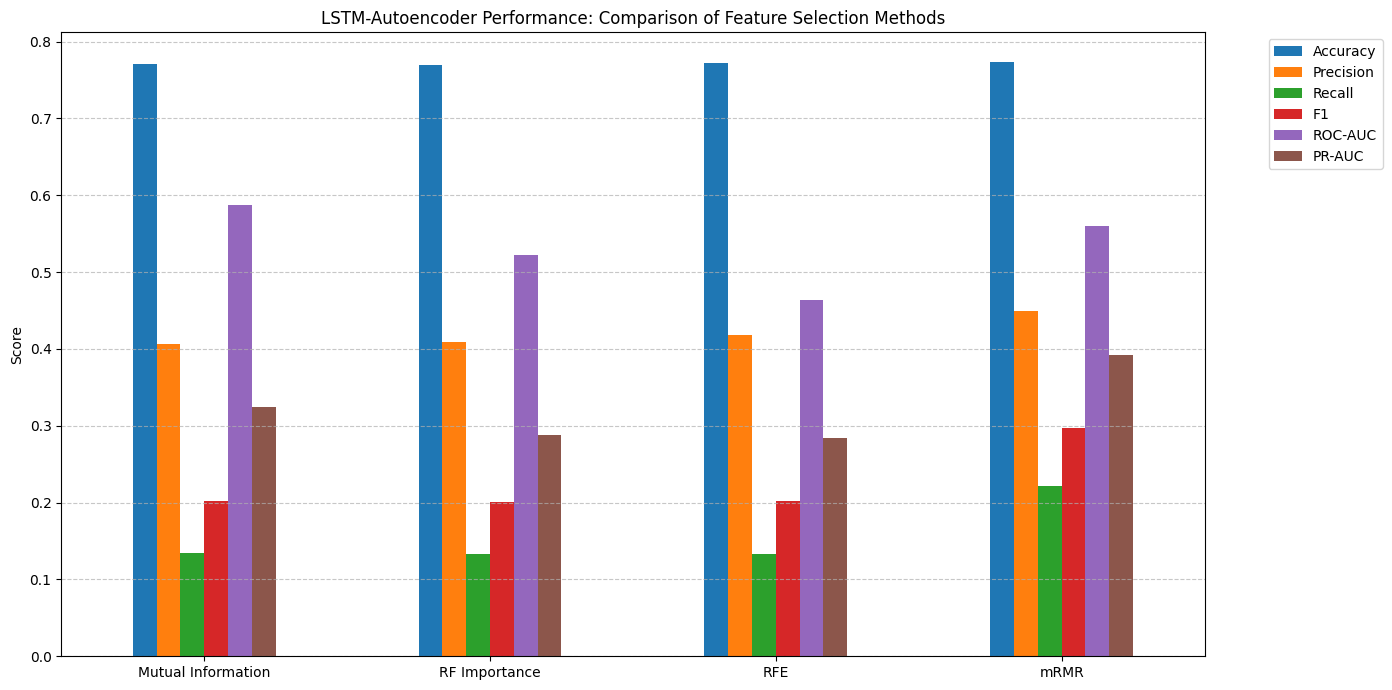

In [11]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
results_df[metrics_to_plot].plot(kind='bar', figsize=(14, 7))
plt.title("LSTM-Autoencoder Performance: Comparison of Feature Selection Methods")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()